In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda x: '%.2f' % x)

analise_campanha_df = pd.read_csv('top_5_ROI_por_localização.csv')

analise_campanha_df.head()

analise_campanha_df.describe()

,Acquisition_Cost_Media,Media_ROI,Conversion_Rate_Media,Total_Campanhas,Rank_ROI_Per_Location
count,25.00,25.00,25.00,25.00,25.00
mean,12530.90,5.07,0.08,1327.12,3.00
std,135.42,0.02,0.00,45.47,1.44
min,12329.30,5.05,0.08,1242.00,1.00
25%,12385.95,5.06,0.08,1284.00,2.00
50%,12523.39,5.07,0.08,1333.00,3.00
75%,12610.11,5.08,0.08,1355.00,4.00
max,12807.37,5.11,0.08,1427.00,5.00


In [14]:

#Analisando para ver o quanto foi investido no total
analise_campanha_df['Total_Investment'] = analise_campanha_df['Acquisition_Cost_Media'] * analise_campanha_df['Total_Campanhas']

#O quanto de retorno bruto tivemos
analise_campanha_df['Gross_Return'] = (analise_campanha_df['Media_ROI'] * analise_campanha_df['Total_Investment']) + analise_campanha_df['Total_Investment']

#O Lucro Liquido
analise_campanha_df['Profit'] = analise_campanha_df['Gross_Return'] - analise_campanha_df['Total_Investment']

df_lucro = analise_campanha_df.sort_values(by='Profit', ascending=False)
display(df_lucro[['Location', 'Channel_Used','Media_ROI', 'Total_Campanhas', 'Total_Investment', 'Profit']].head(10))

,Location,Channel_Used,Media_ROI,Total_Campanhas,Total_Investment,Profit
2,Chicago,Facebook,5.06,1427,17870871.00,90379895.03
15,Miami,YouTube,5.11,1375,17444130.00,89161071.59
1,Chicago,Email,5.07,1356,17199921.00,87233027.06
14,Los Angeles,Google Ads,5.06,1395,17199376.00,86943893.67
23,New York,Website,5.06,1375,17113732.00,86590256.45
13,Los Angeles,Google Ads,5.06,1383,17119593.00,86584910.16
11,Los Angeles,Google Ads,5.07,1333,17072224.00,86584095.75
16,Miami,YouTube,5.08,1352,16986931.00,86210559.47
19,Miami,YouTube,5.05,1345,16949883.00,85677310.83
7,Houston,Google Ads,5.08,1340,16750672.00,85135040.43


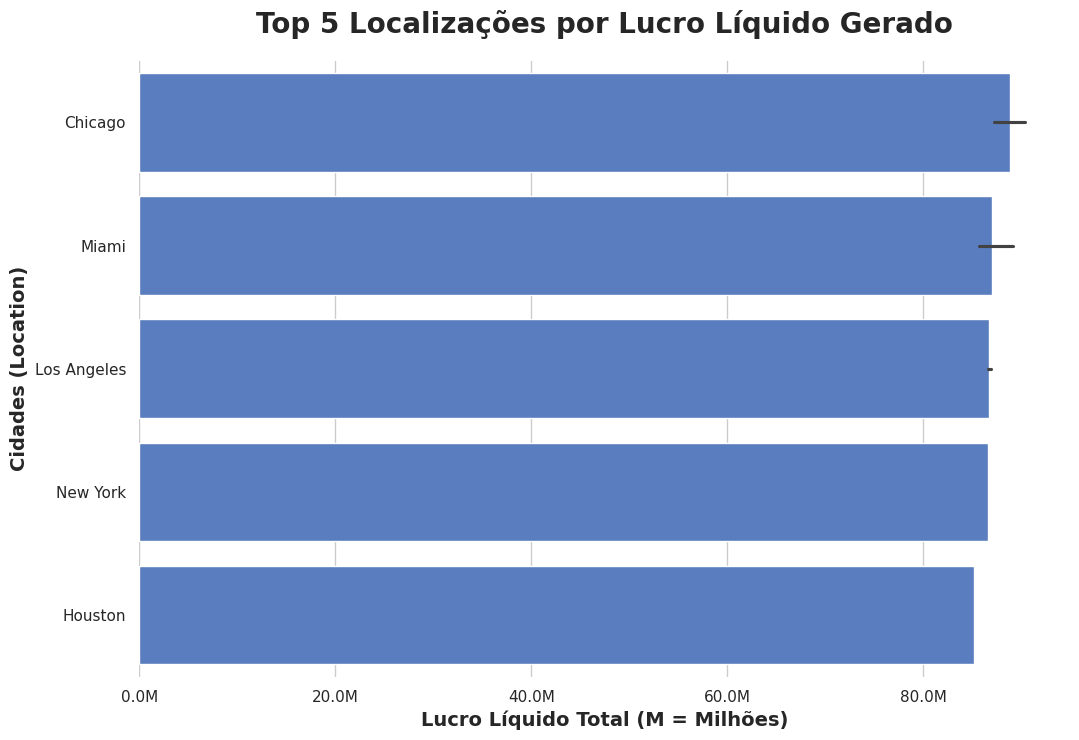

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configurando o estilo visual do gráfico
sns.set_theme(style="whitegrid", palette="muted")

#Definir o tamanho da imagem
plt.figure(figsize=(12, 8))

ax = sns.barplot(x='Profit', y='Location', data=df_lucro.head(10), orient='h')

#Formatando para não mostrar números gigantescos
import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: '{:,.1f}M'.format(x/1e6))
ax.xaxis.set_major_formatter(formatter)

#Adicionando o Título e Rótulos
plt.title('Top 5 Localizações por Lucro Líquido Gerado', fontsize=20, pad=20, fontweight='bold')
plt.xlabel('Lucro Líquido Total (M = Milhões)', fontsize=14, fontweight='bold')
plt.ylabel('Cidades (Location)', fontsize=14, fontweight='bold')

#Removendo bordas desnecessárias
sns.despine(left=True, bottom=True)


plt.show()